Ana Paula K Guimaraes

In [295]:
import pandas as pd

# Pandas, Matplotlib and Seaborn

[Dataset Soruce](https://www.kaggle.com/datasets/rajkumarpandey02/gdp-in-usd-per-capita-income-by-country)

CONTENT
<p>The figures presented here do not take into account differences in the cost of living in different countries, and the results vary greatly from one year to another based on fluctuations in the exchange rates of the country's currency. Such fluctuations change a country's ranking from one year to the next, even though they often make little or no difference to the standard of living of its population.

GDP per capita is often considered an indicator of a country's standard of living; however, this is inaccurate because GDP per capita is not a measure of personal income.

Comparisons of national income are also frequently made on the basis of purchasing power parity (PPP), to adjust for differences in the cost of living in different countries. (See List of countries by GDP (PPP) per capita.) PPP largely removes the exchange rate problem but not others; it does not reflect the value of economic output in international trade, and it also requires more estimation than GDP per capita. On the whole, PPP per capita figures are more narrowly spread than nominal GDP per capita figures.</p>

Here are some resources to learn about GDP:
#### [World Bank](https://data.worldbank.org/indicator/ny.gdp.pcap.cd?most_recent_value_desc=false)
#### [Our World in Data](https://ourworldindata.org/grapher/gdp-per-capita-worldbank)
#### [IMF](https://www.imf.org/external/datamapper/NGDPD@WEO/OEMDC/ADVEC/WEOWORLD)
#### [UN Data](https://data.un.org/Data.aspx?d=SNAAMA&f=grID%3A101%3BcurrID%3AUSD%3BpcFlag%3A1)



First of all, I uploaded and read the file " GDP (nominal) per Capita.csv" and then imported the libraries.

In [296]:
from google.colab import files
uploaded = files.upload()

Saving GDP (nominal) per Capita.csv to GDP (nominal) per Capita (3).csv


In [297]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("GDP (nominal) per Capita.csv",encoding= 'unicode_escape',  index_col=0)


In [298]:
df.head(10)

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
1,Monaco,Europe,0,0,234316,2021,234317,2021
2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,Bermuda,Americas,0,0,114090,2021,112653,2021
6,Norway,Europe,101103,2023,89154,2021,89242,2021
7,Switzerland,Europe,98767,2023,91992,2021,93525,2021
8,Singapore,Asia,91100,2023,72794,2021,66822,2021
9,Isle of Man,Europe,0,0,87158,2019,0,0
10,Cayman Islands,Americas,0,0,86569,2021,85250,2021


In [299]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 1 to 223
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Country/Territory   223 non-null    object
 1   UN_Region           223 non-null    object
 2   IMF_Estimate        223 non-null    int64 
 3   IMF_Year            223 non-null    int64 
 4   WorldBank_Estimate  223 non-null    int64 
 5   WorldBank_Year      223 non-null    int64 
 6   UN_Estimate         223 non-null    int64 
 7   UN_Year             223 non-null    object
dtypes: int64(5), object(3)
memory usage: 15.7+ KB


## EDA (Exploratory Data Analysis)

### Use this section to explore and inspect dataset.

I decided to start by looking at the minimum, maximum, and median values from the three estimation sources. And then I made the same for along of the years.

# Checking how data is organized by Year for each international organization

In [300]:
df['IMF_Year'].unique()


array([   0, 2023, 2020, 2022])

In [301]:
df['IMF_Year'].info()


<class 'pandas.core.series.Series'>
Index: 223 entries, 1 to 223
Series name: IMF_Year
Non-Null Count  Dtype
--------------  -----
223 non-null    int64
dtypes: int64(1)
memory usage: 3.5 KB


In [302]:
print(df['IMF_Year'].dtype)
#print(df['IMF_Year'].head())
#print(df['IMF_Year'].unique())

int64


In [303]:
df['IMF_Year'].value_counts()


,count
IMF_Year,
2023,193
0,26
2020,2
2022,2


In [304]:
df['WorldBank_Year'].unique()


array([2021, 2020, 2019, 2007,    0, 2018, 2014, 2011, 2015])

In [305]:
df['WorldBank_Year'].info()


<class 'pandas.core.series.Series'>
Index: 223 entries, 1 to 223
Series name: WorldBank_Year
Non-Null Count  Dtype
--------------  -----
223 non-null    int64
dtypes: int64(1)
memory usage: 3.5 KB


In [306]:
df['WorldBank_Year'].value_counts()


,count
WorldBank_Year,
2021,199
2020,7
0,7
2019,3
2018,2
2014,2
2007,1
2011,1
2015,1


In [307]:
df['UN_Year'].unique()


array(['2021', '0', '[n 10]2021'], dtype=object)

In [308]:
df['UN_Year'].info()


<class 'pandas.core.series.Series'>
Index: 223 entries, 1 to 223
Series name: UN_Year
Non-Null Count  Dtype 
--------------  ----- 
223 non-null    object
dtypes: object(1)
memory usage: 3.5+ KB


My natural next step is to convert UN_Year to an integer. However, we need to clean some values first. To do this, it is useful to check how many entries we have for each value that needs to be cleaned.

In [309]:
df['UN_Year'].value_counts()

,count
UN_Year,
2021,213
0,9
[n 10]2021,1


Before converting to integer, I had to clean "[n 10]" from 2021.

In [310]:
df['UN_Year'] = df['UN_Year'].astype(str).str.replace('[n 10]', '', regex=False)

In [311]:
df['UN_Year'] = df['UN_Year'].astype('Int64')

Now, I'm just checking the data again

In [312]:
df['UN_Year'].info()

<class 'pandas.core.series.Series'>
Index: 223 entries, 1 to 223
Series name: UN_Year
Non-Null Count  Dtype
--------------  -----
223 non-null    Int64
dtypes: Int64(1)
memory usage: 3.7 KB


In [313]:
df['UN_Year'].unique()

<IntegerArray>
[2021, 0]
Length: 2, dtype: Int64

In [314]:
df['UN_Year'].value_counts()

,count
UN_Year,
2021,214
0,9


#Based on the number of entries available for each year and organisation, I concluded that it is reasonable to work with the World Bank data from 2021, which represents 89% of its entries; the UN data from 2021, which represents 95% of its entries; and, finally, the IMF data from 2023, which represents 97% of its entries, excluding Year 0.

**IMF_Estimate (2023), WorldBank_Estimate (2021) and UN_Estimate (2021): Some statistics**

First, I'm going to find out min, max e median for World Bank 2021 data.

In [315]:
df[df['WorldBank_Year'] == 2021]['WorldBank_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)


,WorldBank_Estimate
min,222.00
max,234316.00
median,6695.00
mean,18224.21


Then for UN 2021 data.

In [316]:
df[df['UN_Year'] == 2021]['UN_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)


,UN_Estimate
min,302.00
max,234317.00
median,6795.00
mean,18514.53


Lastly, for IMF 2023 data.

In [317]:
df[df['IMF_Year'] == 2023]['IMF_Estimate'].agg(
    ['min', 'max', 'median', 'mean']).round(2)


,IMF_Estimate
min,249.00
max,132372.00
median,7058.00
mean,17690.12


#Countries above and below the median.


In the next step, based on the minimum, maximum, and median, we'll look at the countries with values between the minimum and the median, and those above the median.




In [318]:
#create a new variable - below_WorldBank - to keep the countries below medium by WorldBank

below_WorldBank = df[(df["WorldBank_Estimate"] < 6695.0) & (df["WorldBank_Estimate"] != 0)][["Country/Territory", "WorldBank_Estimate"]].sort_values(by="WorldBank_Estimate", ascending=True)
below_WorldBank



,Country/Territory,WorldBank_Estimate
223,Burundi,222
222,Afghanistan,369
216,Somalia,447
218,Central African Republic,461
221,Sierra Leone,480
...,...,...
138,Marshall Islands,6172
121,Belize,6228
122,Libya,6357
120,Albania,6493


In [319]:
# count how many countries there are below the median
below_WorldBank["Country/Territory"].nunique()

103

In [320]:
above_WorldBank = df[df["WorldBank_Estimate"] > 6695.0][["Country/Territory", "WorldBank_Estimate"]].sort_values(by="WorldBank_Estimate", ascending=False)
above_WorldBank

,Country/Territory,WorldBank_Estimate
1,Monaco,234316
2,Liechtenstein,157755
3,Luxembourg,133590
5,Bermuda,114090
4,Ireland,100172
...,...,...
115,Belarus,7302
112,Bosnia and Herzegovina,7143
113,Thailand,7066
125,South Africa,7055


In [321]:
above_WorldBank["Country/Territory"].nunique()

112

There are 103 countries below median and 112 countries above median, based on World Bank data.

In [322]:
below_UN = df[(df["UN_Estimate"] < 6795.0) & (df["UN_Estimate"] != 0)][["Country/Territory", "UN_Estimate"]].sort_values(by="UN_Estimate", ascending=True)
below_UN

,Country/Territory,UN_Estimate
215,Yemen,302
223,Burundi,311
222,Afghanistan,373
220,South Sudan,400
216,Somalia,447
...,...,...
120,Albania,6396
118,North Macedonia,6600
116,Peru,6622
149,Iran,6766


In [323]:
below_UN["Country/Territory"].nunique()

107

In [324]:
above_UN = df[df["UN_Estimate"] > 6795.0][["Country/Territory", "UN_Estimate"]].sort_values(by="UN_Estimate", ascending=False)
above_UN

,Country/Territory,UN_Estimate
1,Monaco,234317
2,Liechtenstein,169260
3,Luxembourg,133745
5,Bermuda,112653
4,Ireland,101109
...,...,...
112,Bosnia and Herzegovina,7143
115,Belarus,7121
113,Thailand,7067
125,South Africa,7055


In [325]:
above_UN["Country/Territory"].nunique()

107

By UN data, there are 107 countries below median and exactly 107 countries above median

In [326]:
below_IMF = df[(df["IMF_Estimate"] < 7058.0) & (df["IMF_Estimate"] != 0)][["Country/Territory", "IMF_Estimate"]].sort_values(by="IMF_Estimate", ascending=True)
below_IMF

,Country/Territory,IMF_Estimate
223,Burundi,249
221,Sierra Leone,415
220,South Sudan,467
219,Malawi,496
218,Central African Republic,534
...,...,...
125,South Africa,6485
124,Ecuador,6642
123,Azerbaijan,6757
122,Libya,6763


In [327]:
below_IMF["Country/Territory"].nunique()

100

In [328]:
above_IMF = df[df["IMF_Estimate"] > 7058.0][["Country/Territory", "IMF_Estimate"]].sort_values(by="IMF_Estimate", ascending=False)
above_IMF

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
8,Singapore,91100
...,...,...
115,Belarus,7944
116,Peru,7772
117,Georgia,7600
118,North Macedonia,7384


In [329]:
above_IMF['Country/Territory'].nunique()

96

Finally, according to the IMF data, there are 100 countries below the median and 96 above it.

In [330]:
# number of countries per region

In [331]:
df['UN_Region'].value_counts()

,count
UN_Region,
Africa,55
Asia,51
Americas,48
Europe,48
Oceania,20
World,1


In [332]:
df.groupby('UN_Region').agg(
    countries = ('Country/Territory', 'nunique')
)

,countries
UN_Region,
Africa,55
Americas,48
Asia,51
Europe,48
Oceania,20
World,1


In [333]:
# Countries in Europe

In [334]:
df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023)][['Country/Territory','IMF_Estimate']]

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
13,Iceland,75180
16,Denmark,68827
18,Netherlands,61098
20,Austria,56802
22,Sweden,55395
23,Finland,54351


In [335]:
count = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023)]['Country/Territory'].count()

print(f'Number of European countries in 2023 IMF data : {count} ')

Number of European countries in 2023 IMF data : 43 


In [336]:
average = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023)]['IMF_Estimate'].mean()

print(f'Average of GPD per capita within European countries: {average:.2f}')

Average of GPD per capita within European countries: 38452.19


Other way to see some statistic measures

In [337]:
summary_Europe = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023)].agg(
    average = ('IMF_Estimate', 'mean'),
    median = ('IMF_Estimate', 'median'),
    minimum = ('IMF_Estimate', 'min'),
    maximum = ('IMF_Estimate', 'max')
)
summary_Europe.round(2)


,IMF_Estimate
average,38452.19
median,31223.00
minimum,4654.00
maximum,132372.00


In [338]:
# Countries in Europe below average

In [339]:
Europe_below_average = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023) & (df['IMF_Estimate'] < average)][["Country/Territory", "IMF_Estimate"]].sort_values(by="IMF_Estimate", ascending=True)
Europe_below_average


,Country/Territory,IMF_Estimate
143,Ukraine,4654
133,Kosovo,5641
127,Moldova,6342
120,Albania,7058
118,North Macedonia,7384
115,Belarus,7944
112,Bosnia and Herzegovina,8223
106,Serbia,10849
103,Montenegro,11289
90,Russia,14403


In [340]:
print(f"Number of European countries below average: \n{Europe_below_average['Country/Territory'].count()}")


Number of European countries below average: 
26


In [341]:
# Countries in Europe above average

In [342]:
Europe_above_average = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023) & (df['IMF_Estimate'] > average)][["Country/Territory", "IMF_Estimate"]].sort_values(by="IMF_Estimate", ascending=False)
Europe_above_average

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
13,Iceland,75180
16,Denmark,68827
18,Netherlands,61098
20,Austria,56802
22,Sweden,55395
23,Finland,54351


In [343]:
print(f"Number of European countries above average: \n{Europe_above_average['Country/Territory'].count()}")


Number of European countries above average: 
17


In [344]:
## Which countries in Europe has higher GDP than UK?

In [345]:
print(f"UK GPD per capita: \n{df[(df['Country/Territory'] == 'United Kingdom') & (df['IMF_Year'] == 2023)]['IMF_Estimate'].iloc[0]}")

UK GPD per capita: 
46371


In [346]:
Countries_above_UK = df[(df['UN_Region'] == 'Europe') & (df['IMF_Year'] == 2023) & (df['IMF_Estimate'] > 46371)][['Country/Territory','IMF_Estimate']]
Countries_above_UK

,Country/Territory,IMF_Estimate
3,Luxembourg,132372
4,Ireland,114581
6,Norway,101103
7,Switzerland,98767
13,Iceland,75180
16,Denmark,68827
18,Netherlands,61098
20,Austria,56802
22,Sweden,55395
23,Finland,54351


In [347]:
print(f"There are {Countries_above_UK['Country/Territory'].count()} countries in Europe above UK GPD per capita")

There are 13 countries in Europe above UK GPD per capita


## groupby()

[Learn more about groupby](https://www.geeksforgeeks.org/pandas-groupby/)

# Summary of each region by the three international organisations

In [348]:
# IMF
df[df['IMF_Year'] == 2023].groupby('UN_Region').agg(
    countries = ('Country/Territory', 'nunique'),
    average = ('IMF_Estimate', 'mean'),
    median = ('IMF_Estimate', 'median'),
    minimum = ('IMF_Estimate', 'min'),
    maximum = ('IMF_Estimate', 'max')
).round(2)

,countries,average,median,minimum,maximum
UN_Region,,,,,
Africa,54,2854.24,1512.0,249,19536
Americas,36,15828.06,11222.5,2173,80034
Asia,45,18682.40,8007.0,573,91100
Europe,43,38452.19,31223.0,4654,132372
Oceania,14,13047.36,5292.5,1989,64964
World,1,13440.00,13440.0,13440,13440


In [349]:
df[df['WorldBank_Year'] == 2021].groupby('UN_Region').agg(
    countries = ('Country/Territory', 'nunique'),
    average = ('WorldBank_Estimate', 'mean'),
    median = ('WorldBank_Estimate', 'median'),
    minimum = ('WorldBank_Estimate', 'min'),
    maximum = ('WorldBank_Estimate', 'max')
).round(2)

,countries,average,median,minimum,maximum
UN_Region,,,,,
Africa,52,2580.38,1607.5,222,14653
Americas,39,18477.38,9999.0,1830,114090
Asia,45,15046.82,4775.0,369,72794
Europe,44,40997.98,28617.5,4836,234316
Oceania,18,15475.89,5902.0,1607,60443
World,1,12235.00,12235.0,12235,12235


In [350]:
df[df['UN_Year'] == 2021].groupby('UN_Region').agg(
    countries = ('Country/Territory', 'nunique'),
    average = ('UN_Estimate', 'mean'),
    median = ('UN_Estimate', 'median'),
    minimum = ('UN_Estimate', 'min'),
    maximum = ('UN_Estimate', 'max')
).round(2)

,countries,average,median,minimum,maximum
UN_Region,,,,,
Africa,55,2417.93,1361.0,311,12085
Americas,46,19516.96,11008.0,1664,112653
Asia,50,14350.40,4971.0,302,66822
Europe,45,43318.18,29135.0,4468,234317
Oceania,17,14839.71,5370.0,1765,66916
World,1,12230.00,12230.0,12230,12230


## Which countries below average by IMF world estimate?

In [351]:
below_average_IMF = df[(df['IMF_Estimate'] <18224.21) & (df['IMF_Year'] == 2023)][['Country/Territory', 'WorldBank_Estimate']]
below_average_IMF

,Country/Territory,WorldBank_Estimate
80,Saint Kitts and Nevis,18083
81,Chile,16265
83,Maldives,10366
84,Panama,14618
87,Bulgaria,12222
...,...,...
218,Central African Republic,461
219,Malawi,635
220,South Sudan,1072
221,Sierra Leone,480


In [352]:
# number of countries below average by IMF world estimate
print(f"Number of countries below average by IMF world estimate: \n{below_average_IMF['Country/Territory'].count()}")

Number of countries below average by IMF world estimate: 
133


In [353]:
above_average_IMF = df[(df['IMF_Estimate'] > 18224.21) & (df['IMF_Year'] == 2023)][['Country/Territory', 'WorldBank_Estimate']]
above_average_IMF

,Country/Territory,WorldBank_Estimate
3,Luxembourg,133590
4,Ireland,100172
6,Norway,89154
7,Switzerland,91992
8,Singapore,72794
11,Qatar,66838
12,United States,70249
13,Iceland,68728
16,Denmark,68008
17,Australia,60443


In [354]:
# number of countries above average by IMF world estimate
print(f"Number of countries above average by IMF world estimate: \n{above_average_IMF['Country/Territory'].count()}")

Number of countries above average by IMF world estimate: 
60


For comparisons between countries using summary statistics, it is better to use the median than the mean in this case. As we can see from the examples below, the median gives us an approximately equal division of the countries, with half below the median and half above it. In the final example, 60 countries are above the mean, while 133 are below it.

### IMF estimate 0 values

In [355]:
df[df['IMF_Estimate'] == 0][['Country/Territory', 'IMF_Estimate']]

,Country/Territory,IMF_Estimate
1,Monaco,0
2,Liechtenstein,0
5,Bermuda,0
9,Isle of Man,0
10,Cayman Islands,0
14,Channel Islands,0
15,Faroe Islands,0
19,Greenland,0
31,British Virgin Islands,0
37,US Virgin Islands,0


If you look at this table without context, you might think that these countries really have a GDP of zero. However, as noted earlier, these zero values are associated with year 0, which appears to be an error. Below, the year columns are shown alongside the estimates to make this clearer.

In [356]:
df[df['IMF_Estimate'] == 0][['Country/Territory', 'IMF_Estimate', 'IMF_Year']]

,Country/Territory,IMF_Estimate,IMF_Year
1,Monaco,0,0
2,Liechtenstein,0,0
5,Bermuda,0,0
9,Isle of Man,0,0
10,Cayman Islands,0,0
14,Channel Islands,0,0
15,Faroe Islands,0,0
19,Greenland,0,0
31,British Virgin Islands,0,0
37,US Virgin Islands,0,0


## Which country has highest UN Estimate?

In [357]:
df[df['UN_Year'] == 2021].sort_values(by='UN_Estimate', ascending=False)[['Country/Territory', 'UN_Estimate']].head(1)

,Country/Territory,UN_Estimate
1,Monaco,234317


## Which country has highest Worlbank Estimate?

In [358]:
df[df['WorldBank_Year'] == 2021].sort_values(by='WorldBank_Estimate', ascending=False)[['Country/Territory', 'WorldBank_Estimate']].head(1)

,Country/Territory,WorldBank_Estimate
1,Monaco,234316


## Which country has highest IMF Estimate?

In [359]:
df[df['IMF_Year'] == 2023].sort_values(by='IMF_Estimate', ascending=False)[['Country/Territory', 'IMF_Estimate']].head(1)

,Country/Territory,IMF_Estimate
3,Luxembourg,132372


## Filling 0 Values by average

In [360]:
import numpy as np

In [361]:
# replace 0 with null values

In [362]:
df_copy = df.copy()


I created a copy of the DataFrame before making these changes because I wanted to preserve the original data and avoid affecting the code and decisions I had made up to that point.

In [363]:
df_copy = df_copy.replace(0, np.nan)


In [364]:
df_copy.info()

<class 'pandas.core.frame.DataFrame'>
Index: 223 entries, 1 to 223
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Country/Territory   223 non-null    object 
 1   UN_Region           223 non-null    object 
 2   IMF_Estimate        197 non-null    float64
 3   IMF_Year            197 non-null    float64
 4   WorldBank_Estimate  216 non-null    float64
 5   WorldBank_Year      216 non-null    float64
 6   UN_Estimate         214 non-null    float64
 7   UN_Year             214 non-null    Int64  
dtypes: Int64(1), float64(5), object(2)
memory usage: 15.9+ KB


As we can see, when

In [365]:
df_copy.isnull().sum()

,0
Country/Territory,0
UN_Region,0
IMF_Estimate,26
IMF_Year,26
WorldBank_Estimate,7
WorldBank_Year,7
UN_Estimate,9
UN_Year,9


In [366]:
# Calculate the average of 'Worldbank_Estimate' and 'UN_Estimate' columns
df[['WorldBank_Estimate', 'UN_Estimate', 'IMF_Estimate']].mean().round(2)


,0
WorldBank_Estimate,18927.42
UN_Estimate,17767.30
IMF_Estimate,15351.63


In [367]:
# Fill the null values in 'imf' column with the calculated average
df_copy['IMF_Estimate'] = df_copy['IMF_Estimate'].fillna(17377.74)
print(df_copy['IMF_Estimate'].mean())

17377.73650224215


In [368]:
df_copy.isnull().sum()

,0
Country/Territory,0
UN_Region,0
IMF_Estimate,0
IMF_Year,26
WorldBank_Estimate,7
WorldBank_Year,7
UN_Estimate,9
UN_Year,9


For this exercise, first I made a copy of the DataFrame. Then I filled the NaN values with the average. Finally, I printed the mean of IMF_Estimate again. As expected, it was the same value, because Python ignores NaN values when calculating the mean.

[Visit this link to learn more about ffill](https://www.w3schools.com/python/pandas/ref_df_ffill.asp)

[Visit this link to learn more about bfill](https://www.w3schools.com/python/pandas/ref_df_bfill.asp)

## Checking Missing Values

In [369]:
df_copy.isnull().sum()

,0
Country/Territory,0
UN_Region,0
IMF_Estimate,0
IMF_Year,26
WorldBank_Estimate,7
WorldBank_Year,7
UN_Estimate,9
UN_Year,9


In [370]:
print(df_copy.isnull().sum().sum())

58


In [371]:
df_copy[df_copy['IMF_Estimate'] == 0]['IMF_Year'].count()

np.int64(0)

## Visualization

In [372]:
import matplotlib.pyplot as plt
import seaborn as sns

### Histogram

The histograms in the first column show the estimates grouped into intervals on the x-axis, while the y-axis shows the number of observations falling within each interval. The graphs in the second column show the years on the x-axis and the number of observations for each year on the y-axis.

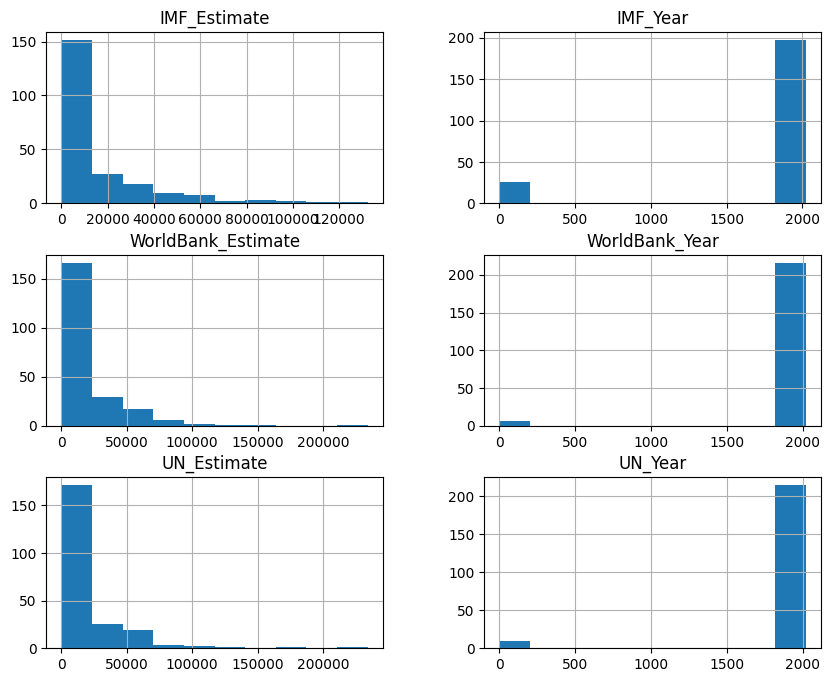

In [373]:
df.hist(figsize=(10,8))
plt.show()

Below, the same code is applied to df_copy, where the zero values were converted to NaN.

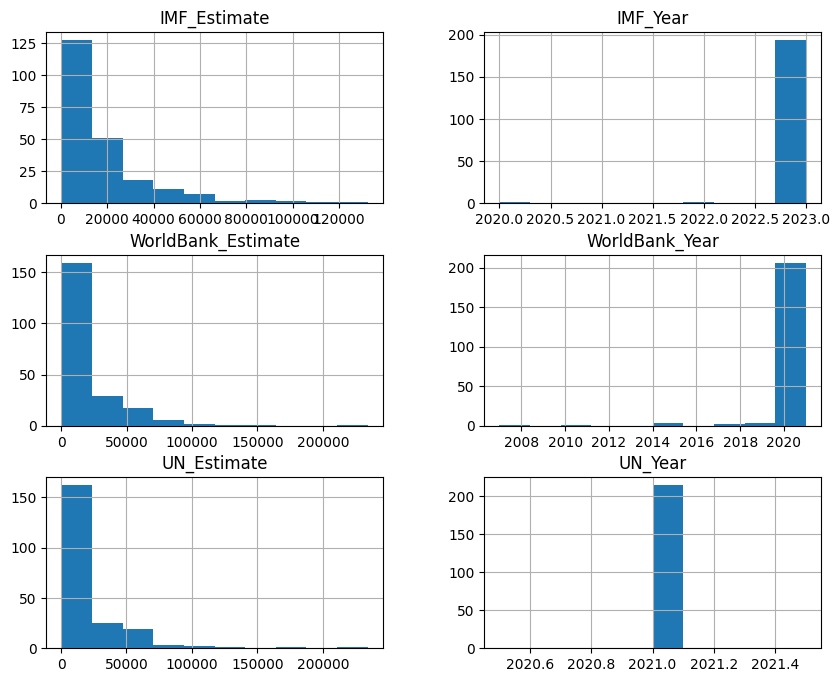

In [374]:
df_copy.hist(figsize=(10,8))
plt.show()

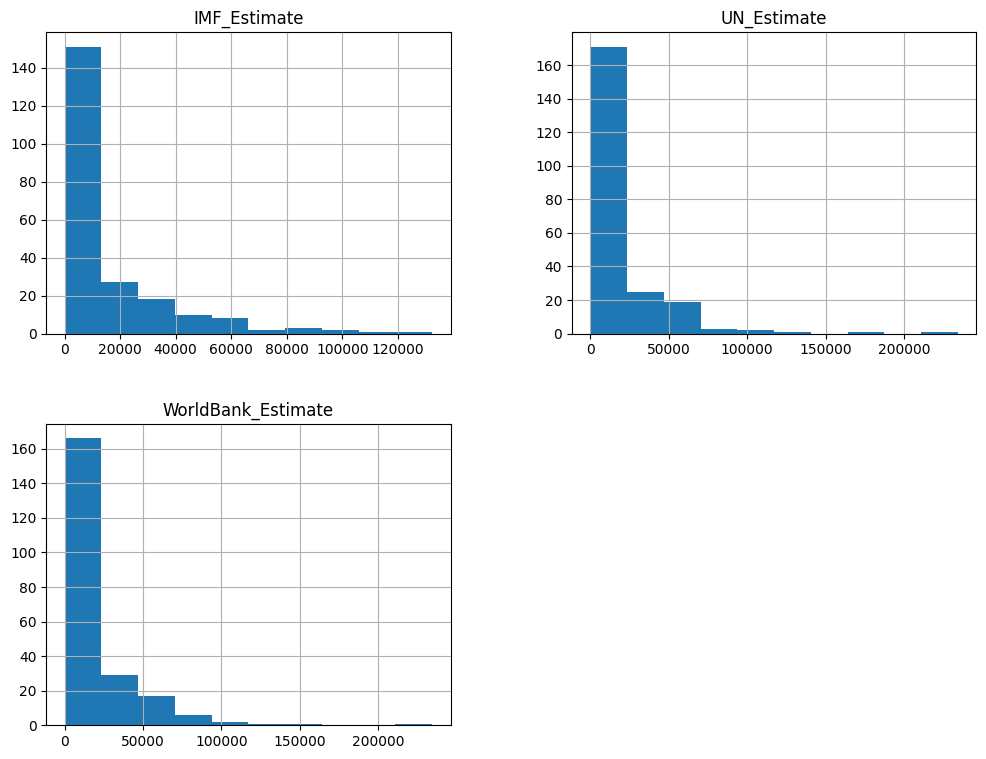

In [375]:
df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].hist(figsize=(12,9))

plt.show()

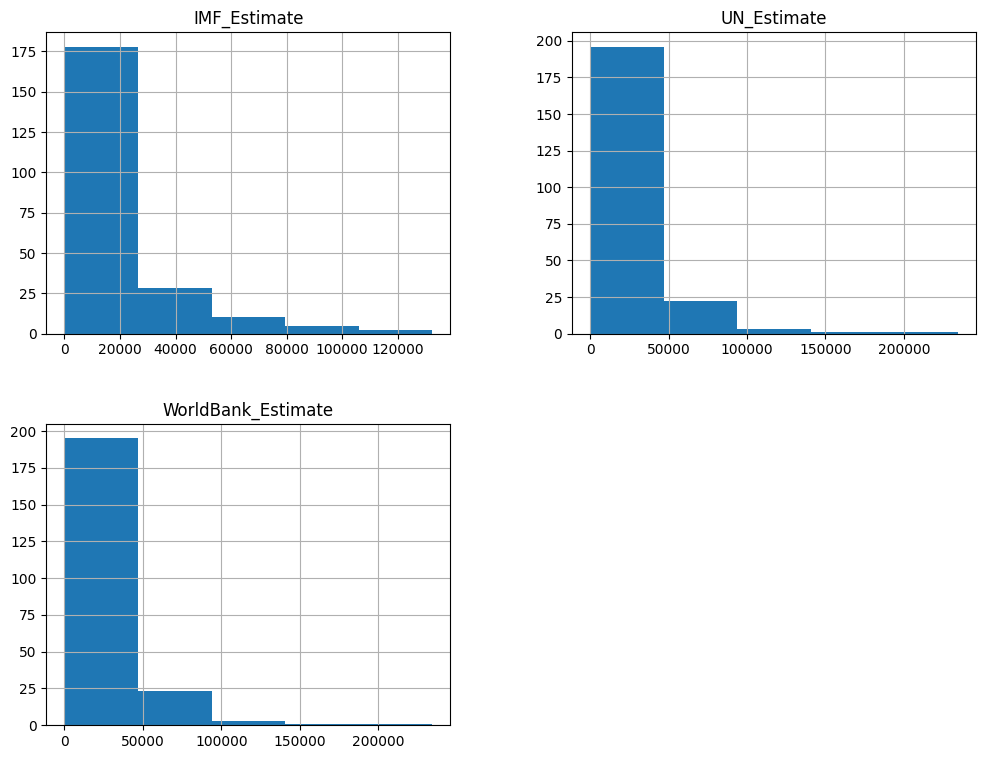

In [376]:
df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].hist(bins=5, figsize=(12,9))

plt.show()

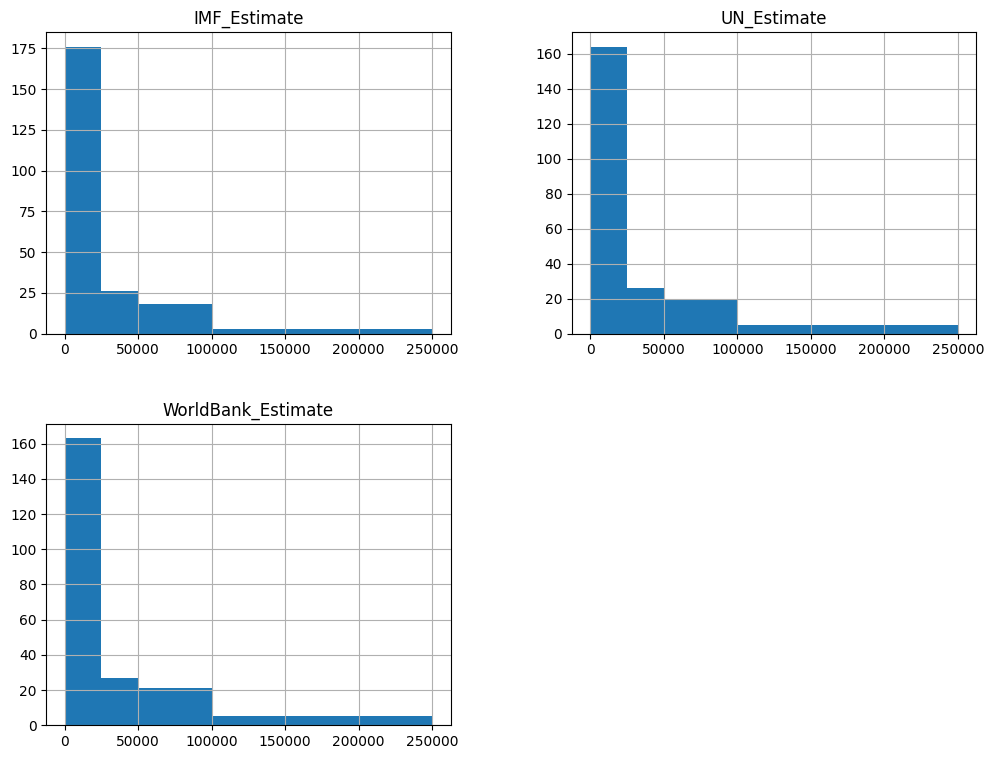

In [377]:
df_copy[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].hist(
    bins=[0, 25000, 50000, 100000, 250000],
    figsize=(12, 9))
plt.show()


In [378]:
df["WorldBank_Estimate"].agg(["min","max"])

,WorldBank_Estimate
min,0
max,234316


In [379]:
234316/5
#1 bin size if bins=5

46863.2

In [380]:
df[df["WorldBank_Estimate"]<=46863.2]["WorldBank_Estimate"].count()

np.int64(195)

In [381]:
234316/10
#1 bin size if bins not given any number

23431.6

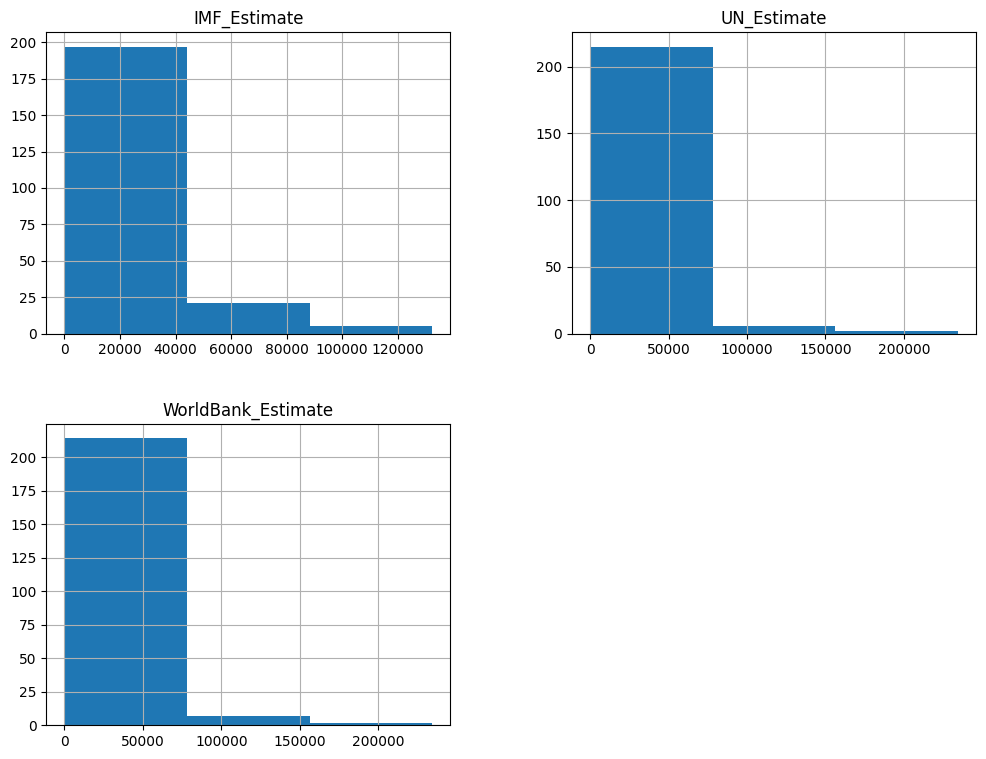

In [382]:
df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].hist(bins=3, figsize=(12,9))

plt.show()

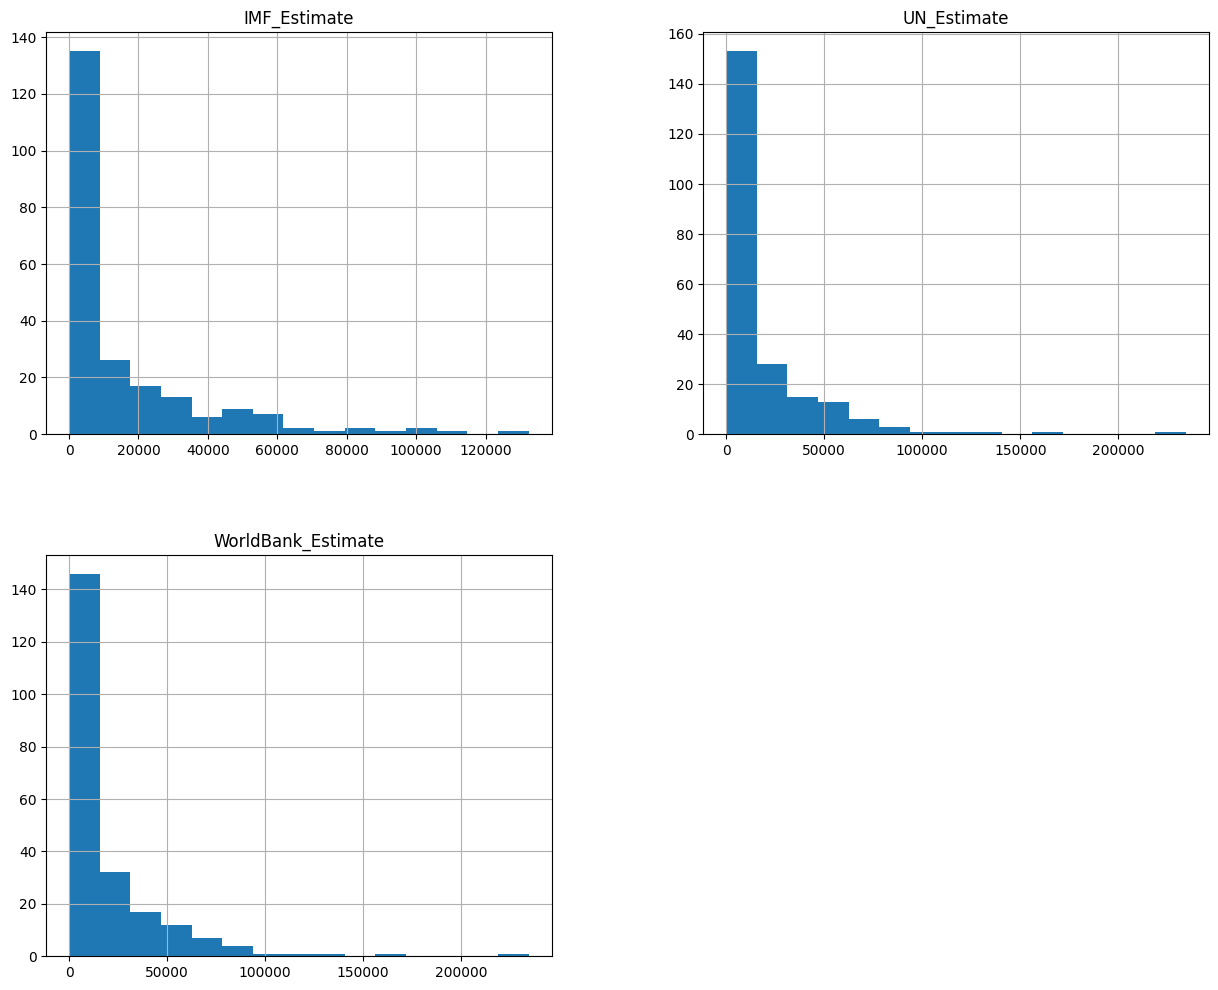

In [383]:
df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].hist(bins=15, figsize=(15,12))

#23400/15 = 15300
plt.show()

### Correlation Heatmap

In [384]:
df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].corr()

,IMF_Estimate,UN_Estimate,WorldBank_Estimate
IMF_Estimate,1.000000,0.626513,0.587988
UN_Estimate,0.626513,1.000000,0.930331
WorldBank_Estimate,0.587988,0.930331,1.000000


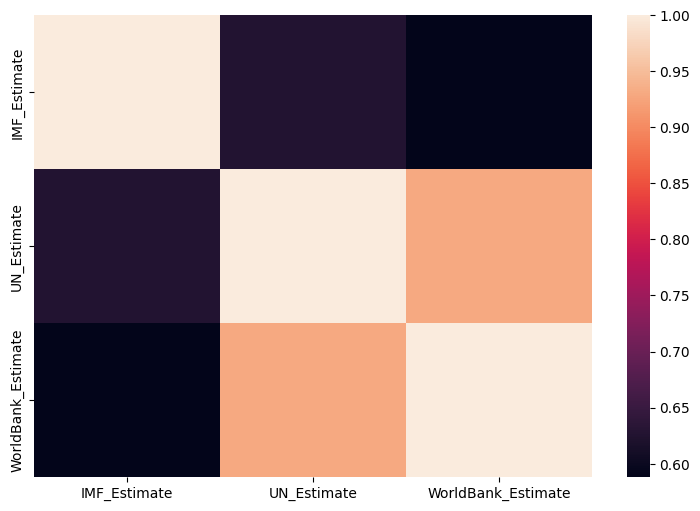

In [385]:
corr = df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].corr()

plt.figure(figsize=(9,6))
sns.heatmap(corr)

plt.show()

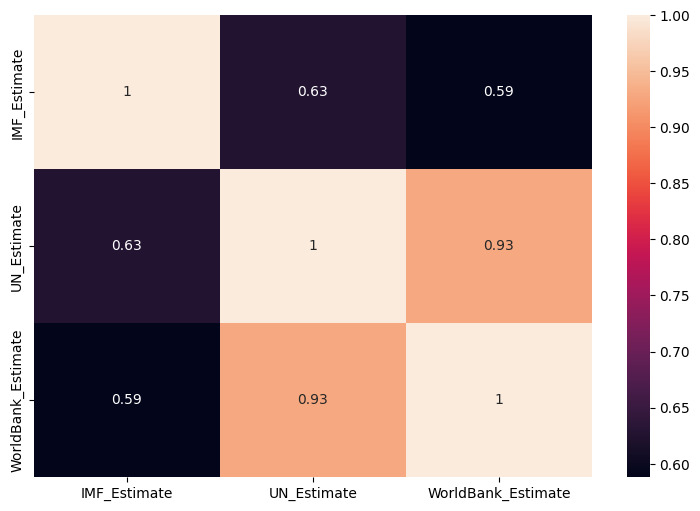

In [386]:
corr = df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].corr()

plt.figure(figsize=(9,6))

sns.heatmap(corr, annot=True)

plt.show()

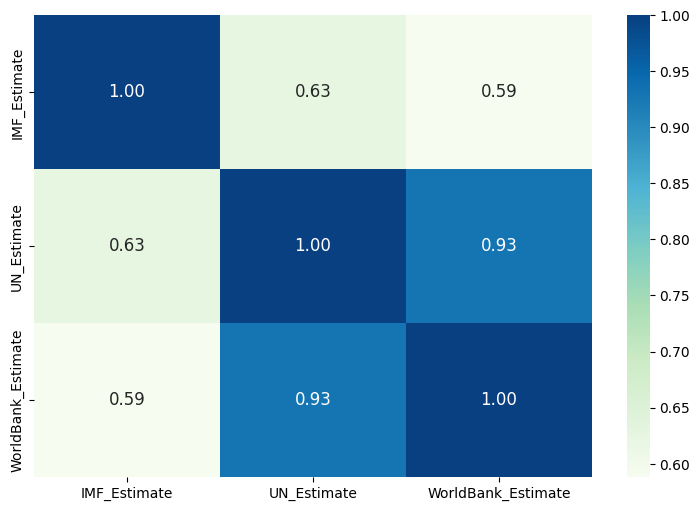

In [387]:
corr = df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].corr()

plt.figure(figsize=(9,6))

sns.heatmap(corr, annot=True, fmt=".2f", cmap = 'GnBu', annot_kws={"size": 12})

plt.show()

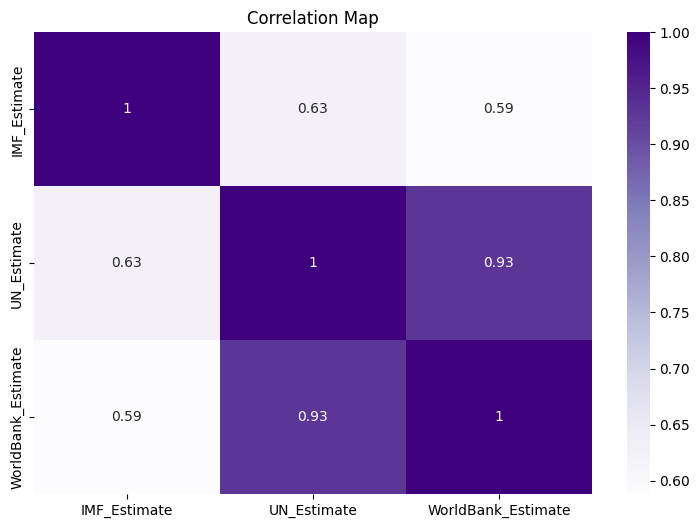

In [388]:
corr = df[["IMF_Estimate", "UN_Estimate", "WorldBank_Estimate"]].corr()

plt.figure(figsize=(9,6))

sns.heatmap(corr, annot=True, cmap = 'Purples')

plt.title("Correlation Map")


plt.show()

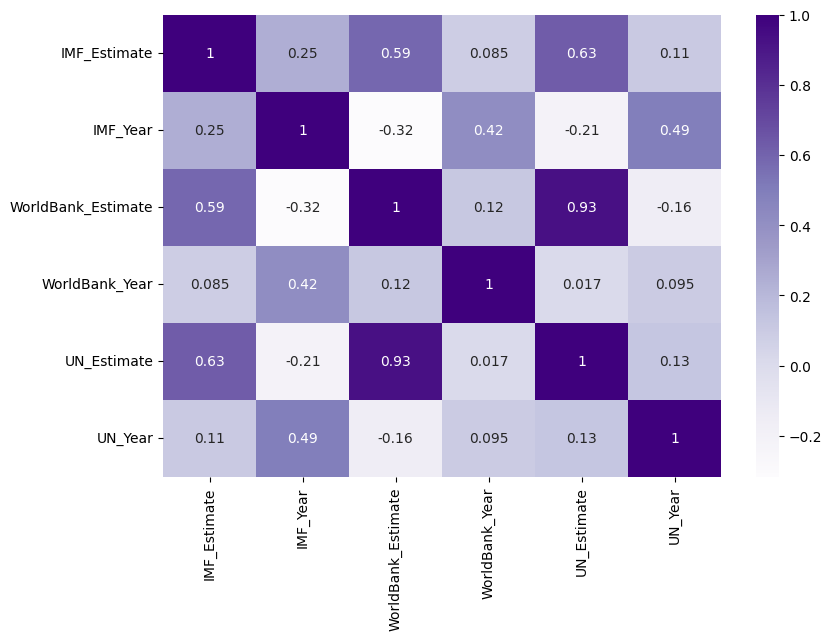

In [389]:
corr = df.select_dtypes(include=[int, float]).corr()

plt.figure(figsize=(9,6))

sns.heatmap(corr, annot=True, cmap = 'Purples')

plt.show()

Below, it'll be showed same heatmaps but now with only the years which have more significant data - WordlBank_Year == 2021, UN_Year == 2021, IMF_Year == 2023.

In [426]:
df[
    (df['WorldBank_Year'] == 2021) &
    (df['UN_Year'] == 2021) &
    (df['IMF_Year'] == 2023)
][['WorldBank_Estimate', 'UN_Estimate', 'IMF_Estimate']].corr().round(2)

,WorldBank_Estimate,UN_Estimate,IMF_Estimate
WorldBank_Estimate,1.00,1.00,0.99
UN_Estimate,1.00,1.00,0.99
IMF_Estimate,0.99,0.99,1.00


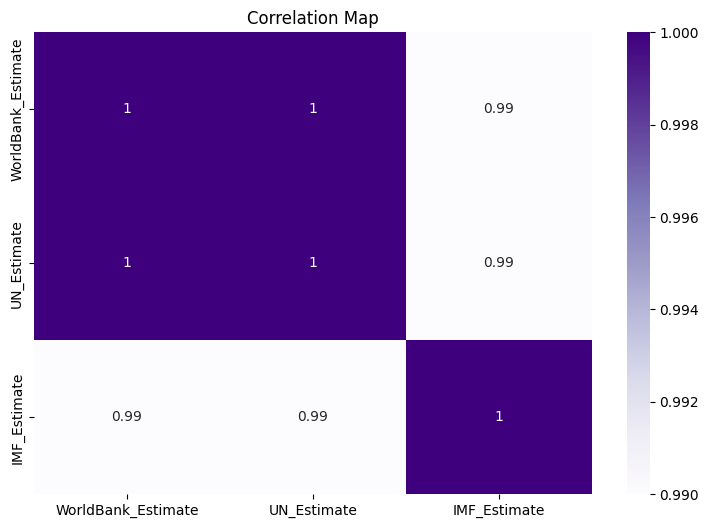

In [427]:
corr = df[
    (df['WorldBank_Year'] == 2021) &
    (df['UN_Year'] == 2021) &
    (df['IMF_Year'] == 2023)
][['WorldBank_Estimate', 'UN_Estimate', 'IMF_Estimate']].corr().round(2)

plt.figure(figsize=(9,6))

sns.heatmap(corr, annot=True, cmap = 'Purples')

plt.title("Correlation Map")


plt.show()



### Bar plot

In [391]:
df.head()

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
1,Monaco,Europe,0,0,234316,2021,234317,2021
2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,Bermuda,Americas,0,0,114090,2021,112653,2021


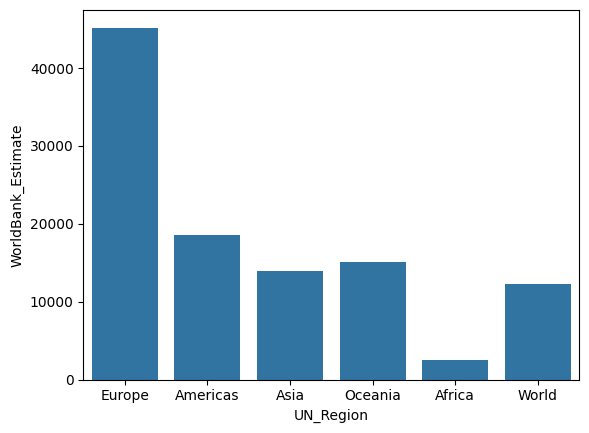

In [392]:
sns.barplot(x="UN_Region", y="WorldBank_Estimate", data=df, errorbar=None)

plt.show()

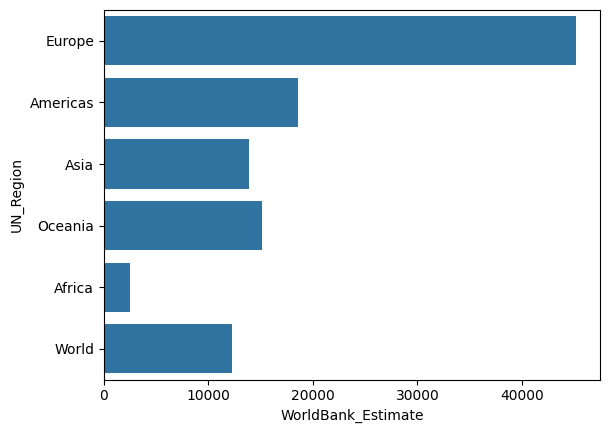

In [393]:
sns.barplot(x="WorldBank_Estimate", y="UN_Region", data=df, errorbar=None)

plt.show()

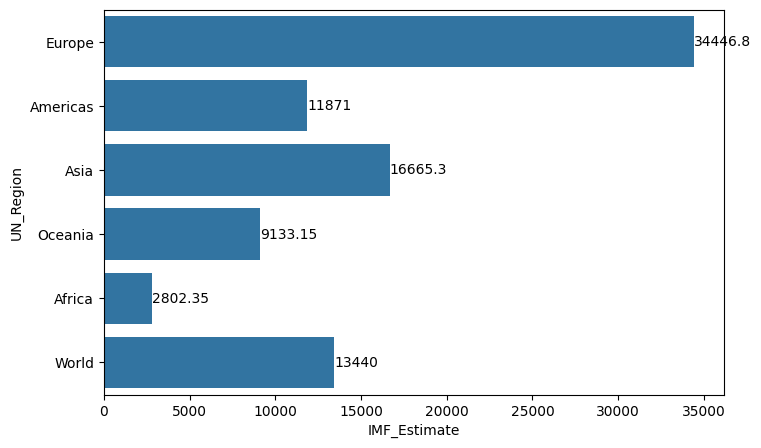

In [394]:
fig = plt.figure(figsize = (8,5))

ax = sns.barplot(x = "IMF_Estimate",  y = "UN_Region",
data = df, errorbar = None)

ax.bar_label(ax.containers[0])

plt.show()

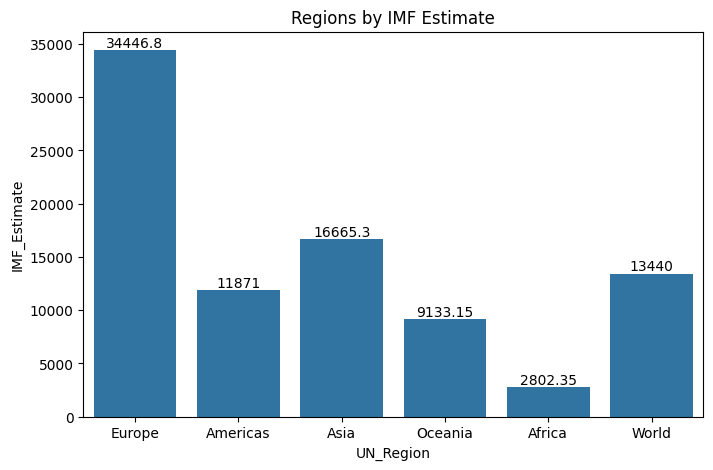

In [395]:
fig = plt.figure(figsize = (8,5))
ax = sns.barplot(x = "UN_Region",  y = "IMF_Estimate",
                 data = df, errorbar = None)

ax.bar_label(ax.containers[0])


ax.set_title("Regions by IMF Estimate")
plt.show()

Since I've been filtering the DataFrame by year, I decided to create a new DataFrame containing only World Bank data from 2021, UN data from 2021, and IMF data from 2023. This way, I can create and analyse the graphs more easily.

In [459]:
df_filtered = df[
    (df['WorldBank_Year'] == 2021) &
    (df['UN_Year'] == 2021) &
    (df['IMF_Year'] == 2023)
][['Country/Territory','UN_Region','WorldBank_Estimate', 'UN_Estimate', 'IMF_Estimate']]
df_filtered.head()

,Country/Territory,UN_Region,WorldBank_Estimate,UN_Estimate,IMF_Estimate
3,Luxembourg,Europe,133590,133745,132372
4,Ireland,Europe,100172,101109,114581
6,Norway,Europe,89154,89242,101103
7,Switzerland,Europe,91992,93525,98767
8,Singapore,Asia,72794,66822,91100


Then, I renamed the columns for clarity.

In [460]:
df_filtered = df_filtered.rename(columns={'WorldBank_Estimate': 'World_Bank/2021'})
df_filtered = df_filtered.rename(columns={'UN_Estimate': 'UN/2021'})
df_filtered = df_filtered.rename(columns={'IMF_Estimate': 'IMF/2023'})
df_filtered.head()

,Country/Territory,UN_Region,World_Bank/2021,UN/2021,IMF/2023
3,Luxembourg,Europe,133590,133745,132372
4,Ireland,Europe,100172,101109,114581
6,Norway,Europe,89154,89242,101103
7,Switzerland,Europe,91992,93525,98767
8,Singapore,Asia,72794,66822,91100


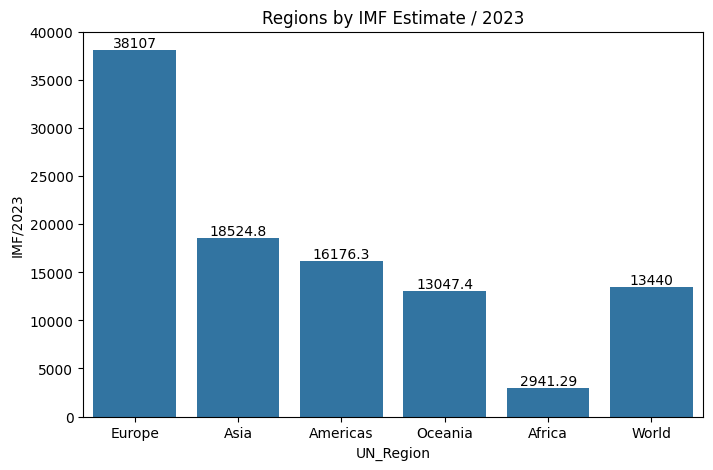

In [439]:
fig = plt.figure(figsize = (8,5))
ax = sns.barplot(x = "UN_Region",  y = "IMF/2023",
    data = df_filtered, errorbar = None)

ax.bar_label(ax.containers[0])


ax.set_title("Regions by IMF Estimate / 2023")
plt.show()

### Scatter Plot

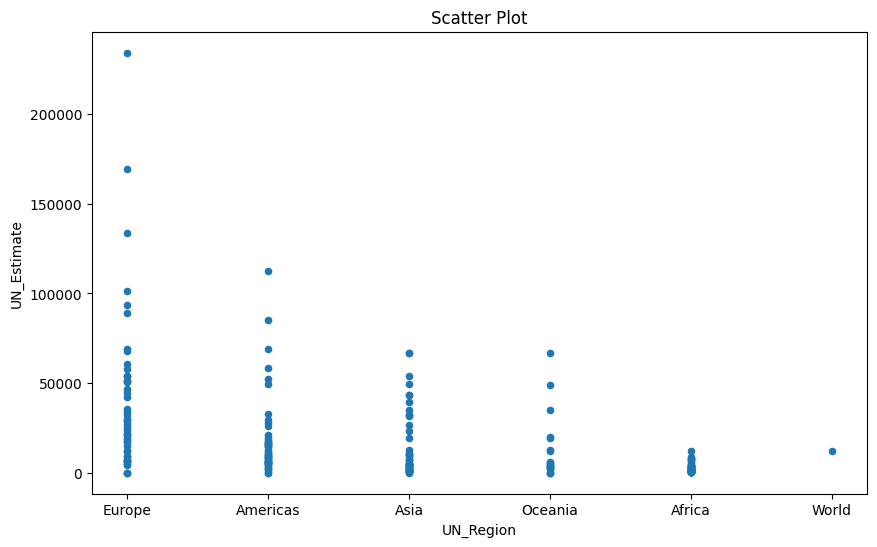

In [396]:
df.plot(x='UN_Region', y='UN_Estimate', kind='scatter',
        figsize=(10,6),
        title="Scatter Plot")

plt.show()

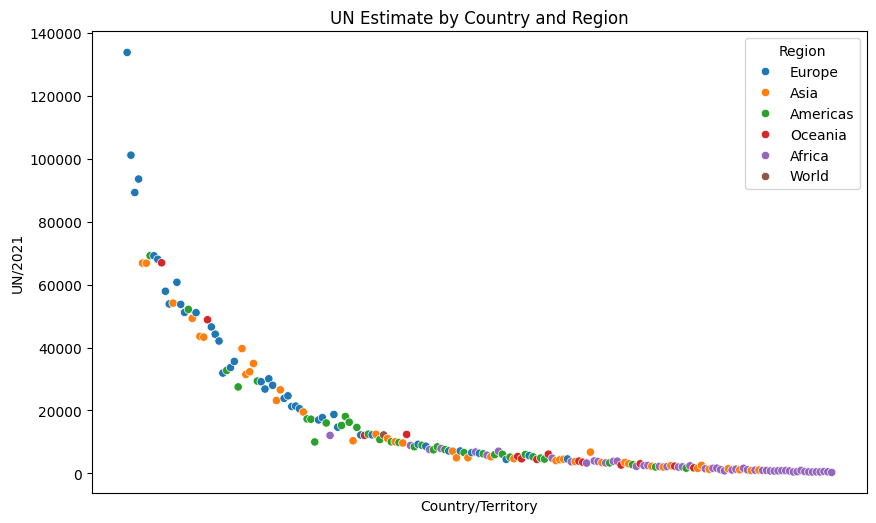

In [461]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered,
    x='Country/Territory',
    y='UN/2021',
    hue='UN_Region'
)

plt.xticks([])
plt.title("UN Estimate by Country and Region")
plt.legend(title="Region")

plt.show()

With the scatter plot above, we can see the distribution of countries in terms of GDP, categorized by region.

# GPD distribution in America

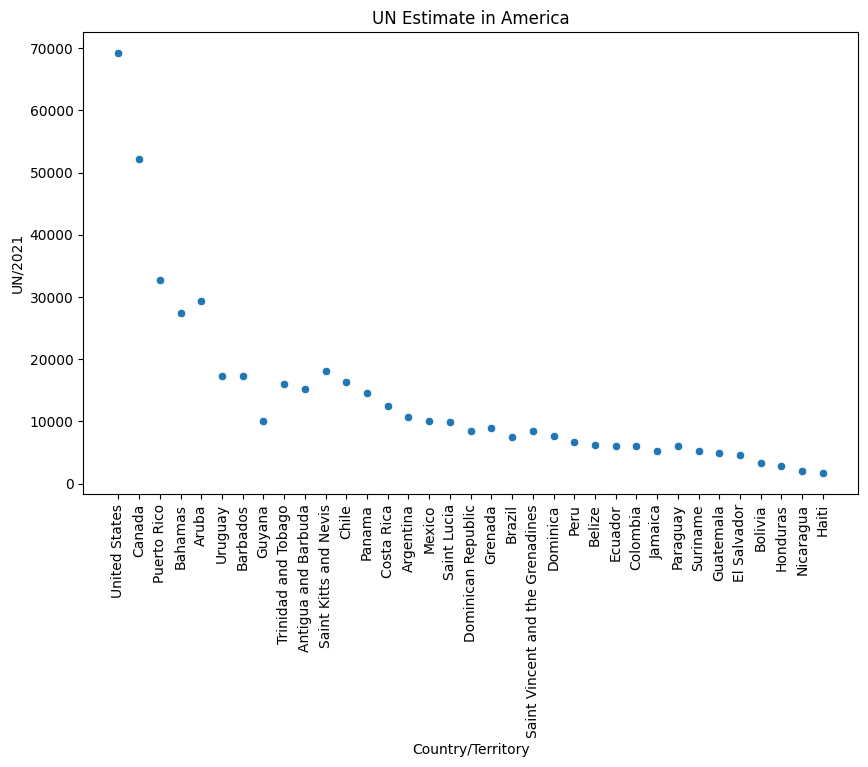

In [462]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['UN_Region'] == 'Americas'],
    x='Country/Territory',
    y='UN/2021'
)
plt.title("UN Estimate in America")
plt.xticks(rotation=90)
plt.show()


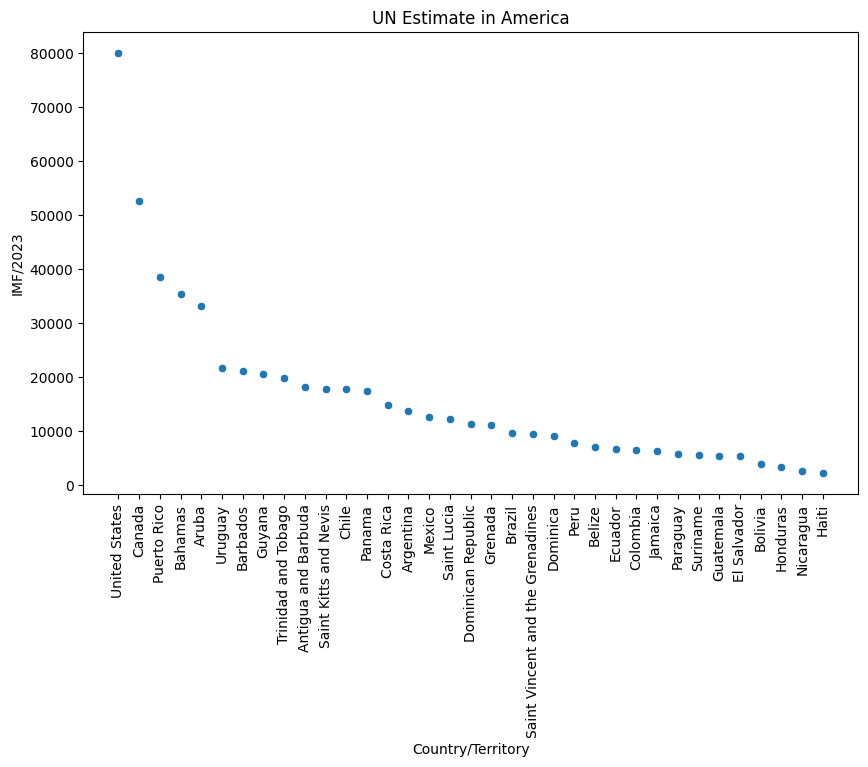

In [452]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['UN_Region'] == 'Americas'],
    x='Country/Territory',
    y='IMF/2023'
)
plt.title("UN Estimate in America")
plt.xticks(rotation=90)
plt.show()

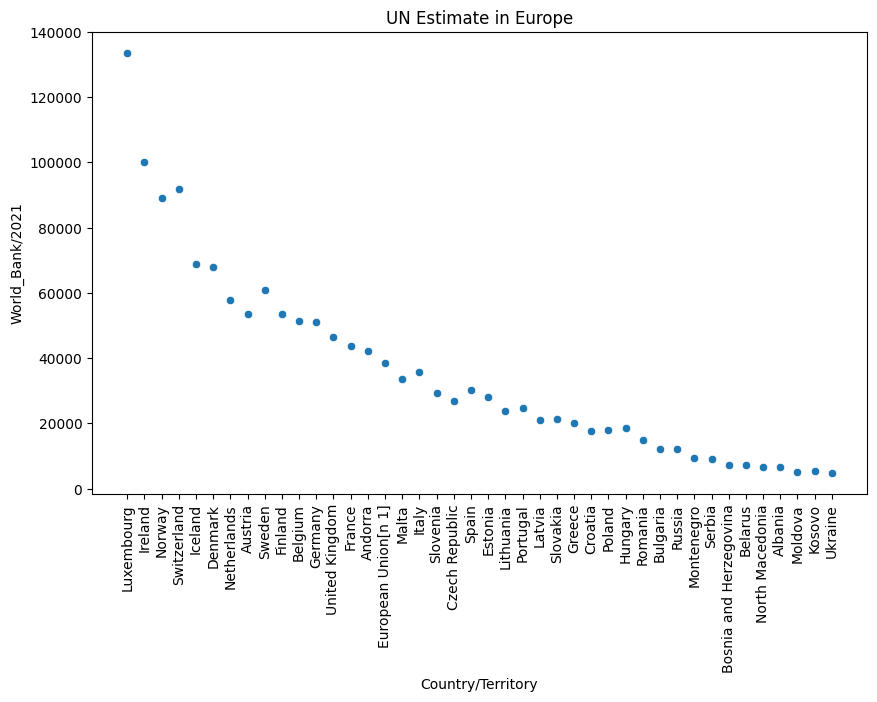

In [454]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df_filtered[df_filtered['UN_Region'] == 'Europe'],
    x='Country/Territory',
    y='World_Bank/2021'
)
plt.title("UN Estimate in Europe")
plt.xticks(rotation=90)
plt.show()

### Boxplot and Outliers

![image.png](attachment:da6a7715-3b1c-4165-a2a9-4dc8ca096bd7.png)

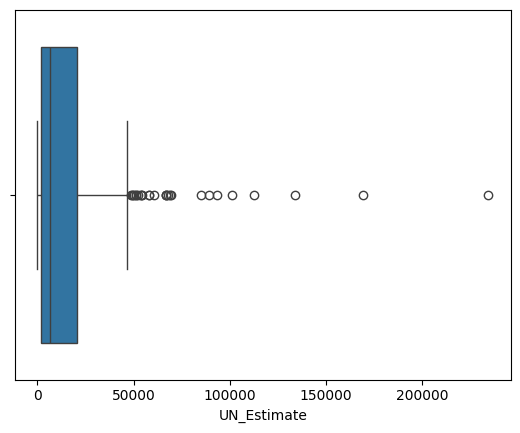

In [397]:
sns.boxplot(x=df["UN_Estimate"])

plt.show()

In [398]:
df[df["UN_Estimate"]>50000].head()

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
1,Monaco,Europe,0,0,234316,2021,234317,2021
2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,Bermuda,Americas,0,0,114090,2021,112653,2021


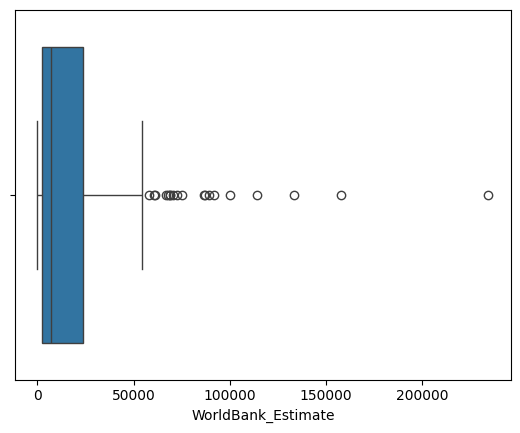

In [399]:
sns.boxplot(x=df["WorldBank_Estimate"])

plt.show()

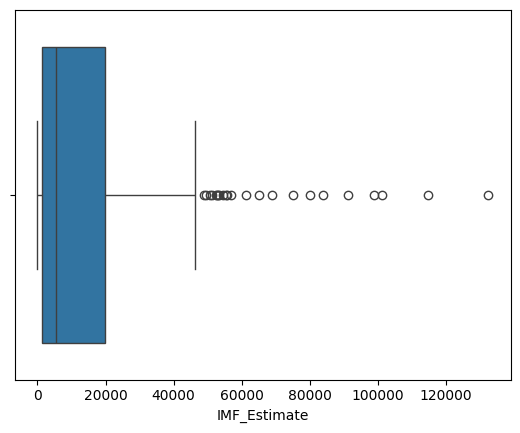

In [400]:
sns.boxplot(x=df["IMF_Estimate"])

plt.show()

In [401]:
df[df["UN_Estimate"]>100000]

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
1,Monaco,Europe,0,0,234316,2021,234317,2021
2,Liechtenstein,Europe,0,0,157755,2020,169260,2021
3,Luxembourg,Europe,132372,2023,133590,2021,133745,2021
4,Ireland,Europe,114581,2023,100172,2021,101109,2021
5,Bermuda,Americas,0,0,114090,2021,112653,2021


In [402]:
df.UN_Estimate.mean()

np.float64(17767.304932735427)

In [403]:
df.shape

(223, 8)

#Boxplot for Americas and Europe



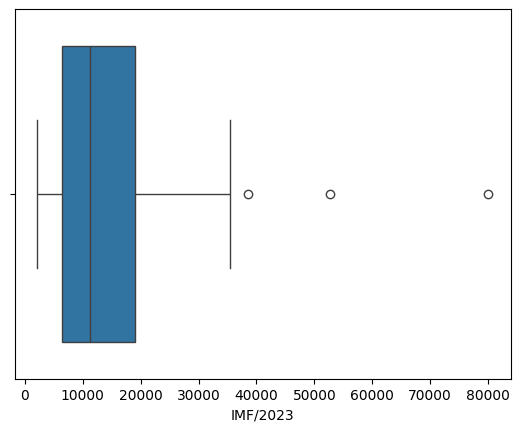

In [466]:
sns.boxplot(x=df_filtered[df_filtered['UN_Region'] == 'Americas']["IMF/2023"])

plt.show()

In [476]:
# Outliers countries in Americas
outlier_Americas = df_filtered[(df_filtered['IMF/2023'] > 36000) & (df_filtered['UN_Region'] == 'Americas')]["Country/Territory"]
outlier_Americas

,Country/Territory
12,United States
26,Canada
38,Puerto Rico


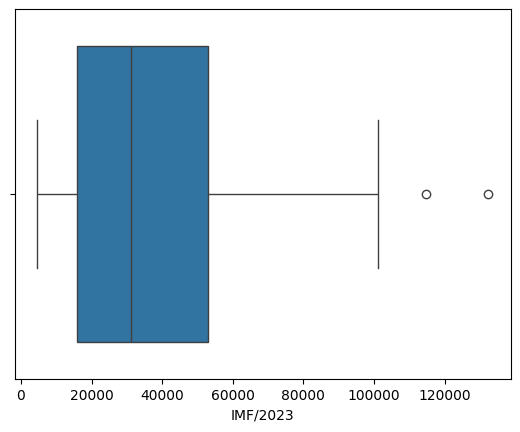

In [473]:
sns.boxplot(x=df_filtered[df_filtered['UN_Region'] == 'Europe']["IMF/2023"])

plt.show()

In [478]:
outliers_Europe = df_filtered[(df_filtered['IMF/2023'] > 105000) & (df_filtered['UN_Region'] == 'Europe')]["Country/Territory"]
outliers_Europe

,Country/Territory
3,Luxembourg
4,Ireland


## Create another dataframe called data excluding  5 countries with highest UN estimate

In [404]:
data = df[-(df["UN_Estimate"]>100000)]

In [405]:
data.head()

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
6,Norway,Europe,101103,2023,89154,2021,89242,2021
7,Switzerland,Europe,98767,2023,91992,2021,93525,2021
8,Singapore,Asia,91100,2023,72794,2021,66822,2021
9,Isle of Man,Europe,0,0,87158,2019,0,0
10,Cayman Islands,Americas,0,0,86569,2021,85250,2021


In [406]:
data.shape

(218, 8)

In [407]:
data.UN_Estimate.mean()

np.float64(14729.47247706422)

In [408]:
df.UN_Estimate.mean()

np.float64(17767.304932735427)

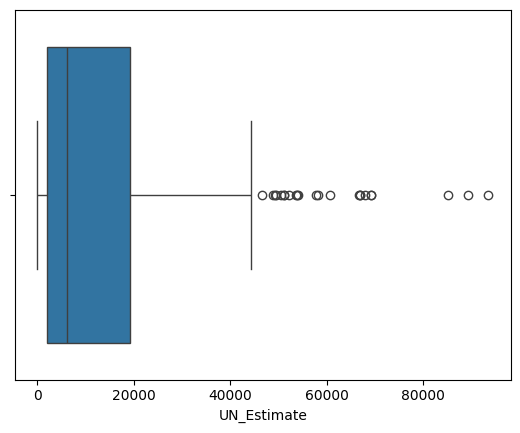

In [463]:
sns.boxplot(x=data["UN_Estimate"])
plt.show()

## Removing outliers

![image.png](attachment:da6a7715-3b1c-4165-a2a9-4dc8ca096bd7.png)

![image.png](attachment:image.png)

In [410]:
lower_q = df["UN_Estimate"].quantile(0.25)
lower_q

np.float64(2039.0)

In [411]:
higher_q = df["UN_Estimate"].quantile(0.75)
higher_q

np.float64(20740.0)

In [412]:
iqr = higher_q - lower_q
iqr

np.float64(18701.0)

In [413]:
upper_boundary = higher_q + 1.5 * iqr
upper_boundary

np.float64(48791.5)

In [414]:
lower_boundary = lower_q - 1.5 * iqr
lower_boundary

np.float64(-26012.5)

In [415]:
df_filtered = df[(df["UN_Estimate"] < upper_boundary) & (df["UN_Estimate"] > lower_boundary)]

In [416]:
df_filtered.head()

,Country/Territory,UN_Region,IMF_Estimate,IMF_Year,WorldBank_Estimate,WorldBank_Year,UN_Estimate,UN_Year
9,Isle of Man,Europe,0,0,87158,2019,0,0
14,Channel Islands,Europe,0,0,75153,2007,0,0
15,Faroe Islands,Europe,0,0,69010,2021,0,0
29,Macau,Asia,50571,2023,43874,2021,43555,2021
30,United Arab Emirates,Asia,49451,2023,44316,2021,43295,2021


In [417]:
df_filtered.shape
# there were 223 rows - 196 = 27 outliers dropped

(196, 8)

In [418]:
df_filtered.UN_Estimate.mean()

np.float64(9415.168367346938)

In [419]:
df.UN_Estimate.mean()

np.float64(17767.304932735427)

In [420]:
#how can we create a table with following
df_filtered.WorldBank_Estimate.mean()

np.float64(11096.647959183674)

In [421]:
df.WorldBank_Estimate.mean()

np.float64(18927.417040358745)

In [422]:
df_filtered.IMF_Estimate.mean()

np.float64(9784.326530612245)

In [423]:
df.IMF_Estimate.mean()

np.float64(15351.632286995517)

#Conclusion
Overall, this analysis helped to identify some important patterns and limitations in the GDP per capita data. After cleaning the dataset and selecting the most representative years for each organisation — 2021 for the World Bank and UN, and 2023 for the IMF — it was possible to make more meaningful comparisons between countries and regions.

The distributions showed that GDP per capita is highly uneven, with many countries concentrated at lower values and a smaller number reaching very high values. Because of this, the median was particularly useful for comparing countries, as the mean was more affected by the highest values. The regional analysis also showed clear differences in GDP per capita across regions.

Finally, the analysis highlighted the importance of checking data quality before drawing conclusions. Values associated with year 0, missing values, and differences in the years reported by each organisation could otherwise lead to misleading results. Although the three organisations provide similar types of estimates, the differences in reporting years should be considered when comparing them directly.